In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True #False if your computer sucks (mine does)

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

m1 = 1e6
m2 = 10
a = 0.96 # 0.95
e0 = 0.5 # 0.6 just spin first
xI0 = 1.0
dist = 0.4
qS = xp.pi/4
phiS = 1.0
qK = 1 
phiK = xp.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 0.4

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.0

print(use_gpu)

True


In [4]:
SK_traj = EMRIInspiral(func=SuperKludgeFlux,use_gpu=use_gpu)
add_args= [chi2, evolve_1PA, evolve_primary, evolve_2PA,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p0_ = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1, m2, a, e0, xI0, *add_args])
print(p0_)

5.37360506310767


In [5]:
filename= "rishav_CVBias"

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

# with longer signals we care less about this
t0 = 10000.0  # throw away on both ends when our orbital information is weird

In [6]:
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

print(use_gpu)
der_order = 8
Ndelta=8
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = True,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=True
                       )
                   

der_order = 12
Ndelta = 8
stability_plot = True

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
emri_kwargs = {"T":T, "dt":dt}
# sef.waveform_generator.backend.uses_cupy

True


In [7]:

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape:  (2, 1262326)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.96, 7.0, 0.5, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  69.12964837739784


In [8]:
# got from Shubham's code
def cutlervallis(waveform_truth, waveform_approx, Fisher_truth, partial_approx, params_truth, PSD_func, dt, use_gpu=False):
    """
    Calculate best-fit param points using the Cutler-Vallisneri linear-bias approximation.
    params:
        waveform_truth (ndarray) : the time-series waveform from the true template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        waveform_approx (ndarray) : the time-series waveform from the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        partial_approx (ndarray) : the time-series partial derivative of the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        Fisher_truth (ndarray) : the Fisher matrix (log-mass units) at params_truth. ndarray of shape 'd x d'
        params_truth (ndarray) : the array of true params. ndarray of shape 'd'
        PSD_func (ndarray) : the frequency-domain LISA noise sensitivity curve. ndarray of shape 'N x L' where L is the length of the frequency series. 

    returns:
        CV_bias (ndarray): params_truth + np.linalg.inv(Fisher_truth) @ inner_product(partial_approx, waveform_truth - waveform_approx)
    """

#Equation 29 of cutler-vallisneri paper
    if use_gpu:
        xp = cp
    else:
        xp = np
        
    #waveform_truth = padding(waveform_truth, waveform_approx, use_gpu = use_gpu) #make waveform_truth the same length as waveform_approx
    delta_wave = waveform_truth - waveform_approx
    #truth contains 1 order PN and approx contains 0 order PN with deviations

    # calculate all the column-wise inner products
    inn_prods = []
    
    for j in range(len(Fisher_truth)):
        
        print("delta_wave.shape, partial_approx.shape: ", delta_wave.shape, partial_approx[j].shape)
                      
        inn_prod_j = inner_product(partial_approx[j], delta_wave, PSD=PSD_func, dt=dt, use_gpu = use_gpu) #should be a scalar
        if not use_gpu:
            inn_prod_j = xp.asarray(inn_prod_j)
        else:
            inn_prod_j = xp.asnumpy(inn_prod_j)
            
        print(f'inner_prod at j = {j}: ', inn_prod_j)
        inn_prods.append(inn_prod_j)
        
    inn_prods = np.array(inn_prods)
    # calculate all the param shifts
    delta_param_all = []
    
    for i in range(len(Fisher_truth)):
            
        delta_param_i = np.linalg.inv(Fisher_truth)[i,:]@inn_prods  #should be a scalars
        print(f"{param_names[i]} have delta {delta_param_i}")
        delta_param_all.append(delta_param_i)
        
    print('delta_param_all: ', delta_param_all)
    return params_truth + np.array(delta_param_all)


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 1262326)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.96, 7.0, 0.5, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 69.12964837739784
calculating stable deltas...
Gamma_ii for m1: 386.53484955664084
Gamma_ii for m1: 386.5348495565058
Gamma_ii for m1: 386.53484955421476
Gamma_ii for m1: 386.5348495832107
Gamma_ii for m1: 386.5348495284645
Gamma_ii for m1: 386.53484956601073
Gamma_ii for m1: 386.53484893653643
Gamma_ii for m1: 386.5348487837779
Gamma_ii for m1: 386.53484865555106
Gamma_ii for m1: 386.53485622913723
Gamma_ii for m1: 386.5348846257712
Gamma_ii for m1: 386.5349194344787
[np.float64(3.494121251117256e-13), np.float64(5.927064937115513e-12), np.float64(7.501507737012942e-11), np.float64(1.416332343350764e-10), np.float64(9.713539430686943e-11), np.float64(1.6285059470622622e-09), np.

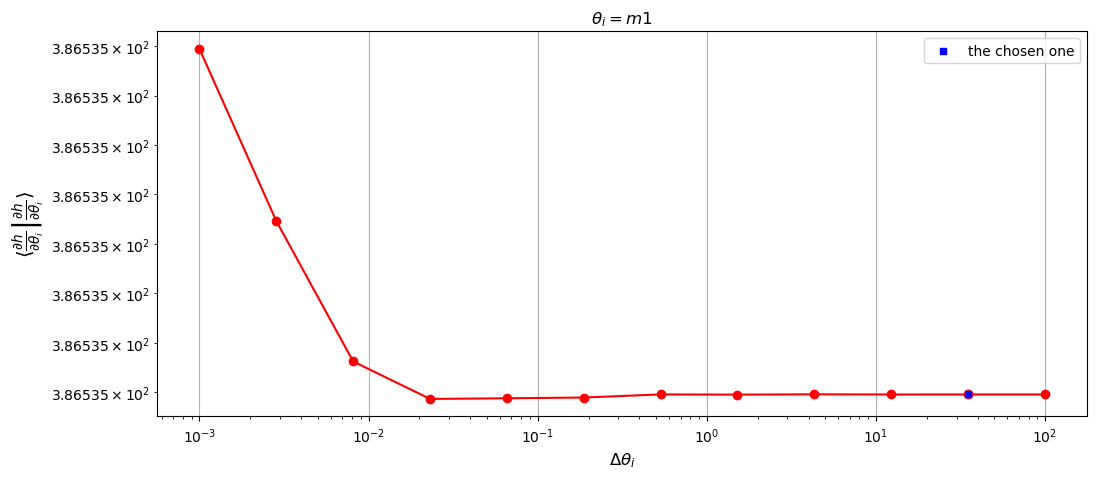

Gamma_ii for m2: 32114672898.86997
Gamma_ii for m2: 32114672897.01079
Gamma_ii for m2: 32114672911.31718
Gamma_ii for m2: 32114672902.370853
Gamma_ii for m2: 32114672991.03102
Gamma_ii for m2: 32114673050.306065
Gamma_ii for m2: 32114672795.74423
Gamma_ii for m2: 32114671089.68583
Gamma_ii for m2: 32114674025.5974
Gamma_ii for m2: 32114666657.96458
Gamma_ii for m2: 32114671393.39805
Gamma_ii for m2: 32114699060.340847
[np.float64(5.789181293250034e-11), np.float64(4.4547826765935736e-10), np.float64(2.785744459135437e-10), np.float64(2.76073705370915e-09), np.float64(1.8457308718260146e-09), np.float64(7.926652027929421e-09), np.float64(5.3123956787101236e-08), np.float64(9.141962858357462e-08), np.float64(2.294164500786493e-07), np.float64(1.474538976238279e-07), np.float64(8.615040342315093e-07)]
0


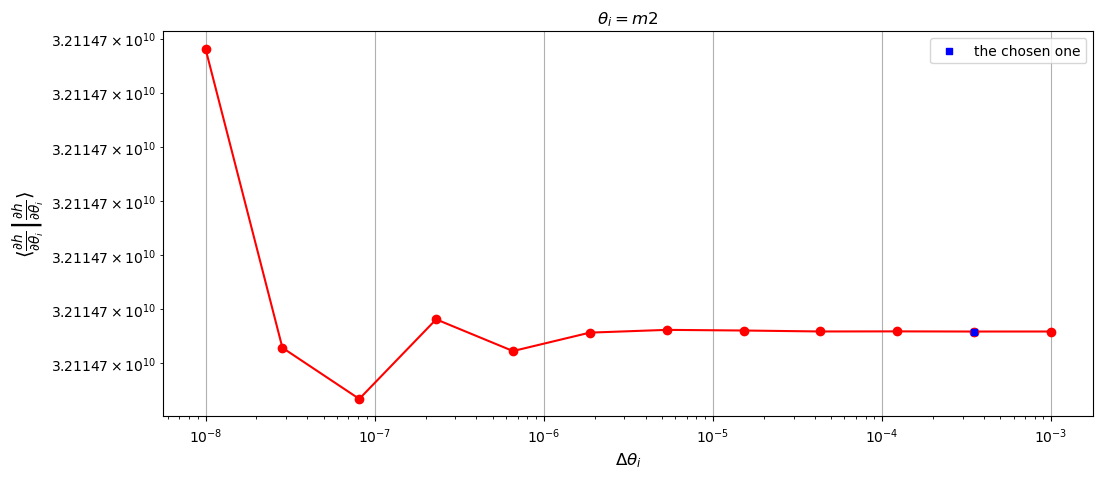

Gamma_ii for a: 1586871390673.0752
Gamma_ii for a: 1586935384830.9897
Gamma_ii for a: 1586744312694.7993
Gamma_ii for a: 1586699480482.2898
Gamma_ii for a: 1587390947315.6545
Gamma_ii for a: 1589185922706.6138
Gamma_ii for a: 1584690894997.611
Gamma_ii for a: 1604722435984.9495
Gamma_ii for a: 1641857241931.6807
Gamma_ii for a: 1466972235709.6765
Gamma_ii for a: 1922521349766.2754
Gamma_ii for a: 2391565074112.22
[np.float64(4.032562291209243e-05), np.float64(0.00012041772241548362), np.float64(2.8255011778219262e-05), np.float64(0.00043559958215337304), np.float64(0.0011294936390464153), np.float64(0.0028365328047205455), np.float64(0.012482869646577468), np.float64(0.022617560771021297), np.float64(0.11921493942753464), np.float64(0.236953994873441), np.float64(0.19612417384045464)]
2


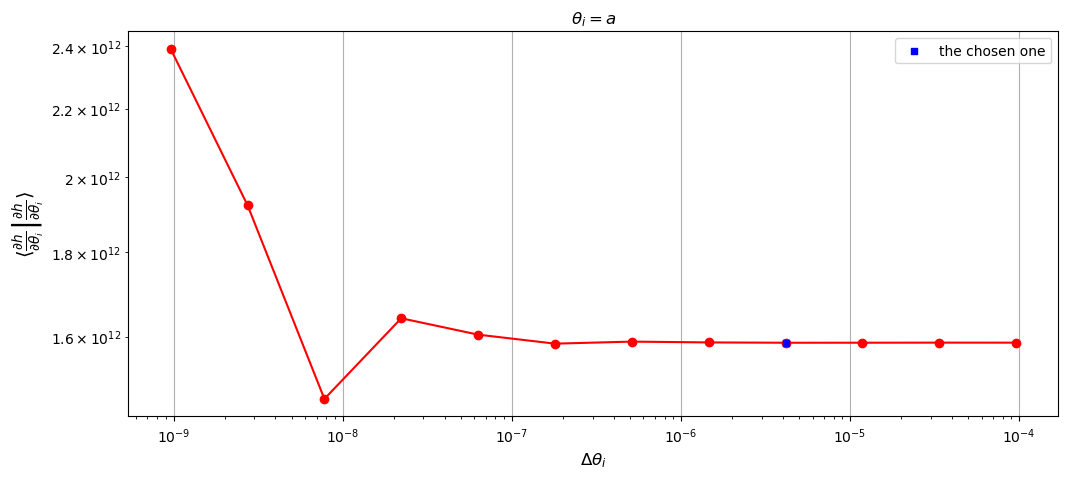

Gamma_ii for p0: 16509260978665.822
Gamma_ii for p0: 16509260504266.865
Gamma_ii for p0: 16509261544035.674
Gamma_ii for p0: 16509262463622.877
Gamma_ii for p0: 16509249180232.453
Gamma_ii for p0: 16509291447840.43
Gamma_ii for p0: 16509182478639.611
Gamma_ii for p0: 16508759461716.5
Gamma_ii for p0: 16507268591236.57
Gamma_ii for p0: 16505019835168.174
Gamma_ii for p0: 16532204891923.67
Gamma_ii for p0: 16524745875188.867
[np.float64(2.873532445070088e-08), np.float64(6.298093986943885e-08), np.float64(5.570128920969381e-08), np.float64(8.046029397710679e-07), np.float64(2.560231498129588e-06), np.float64(6.600520707754552e-06), np.float64(2.5623786214360707e-05), np.float64(9.031600059631703e-05), np.float64(0.0001362467958750909), np.float64(0.0016443696974005305), np.float64(0.0004513846561478503)]
0


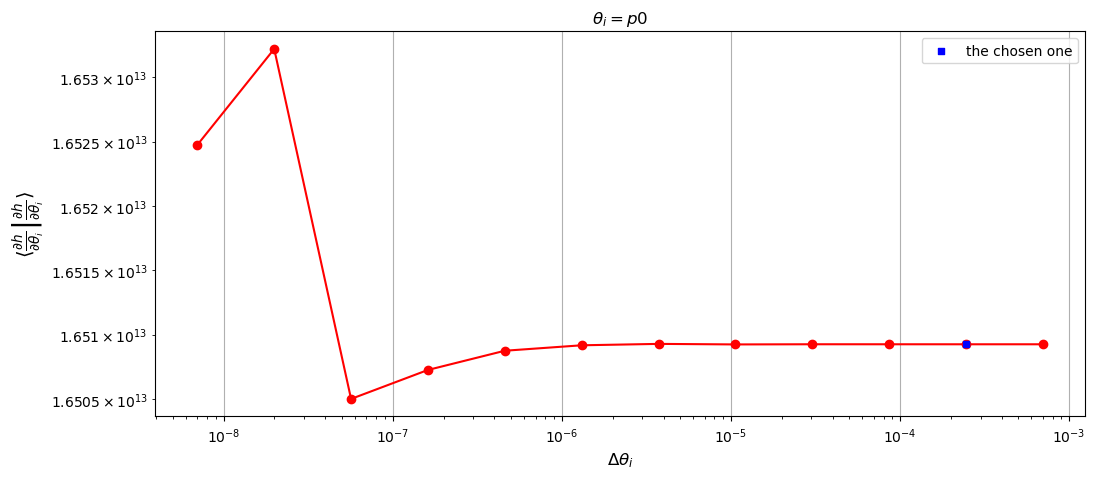

Gamma_ii for e0: 546975939468156.56
Gamma_ii for e0: 546976014549352.56
Gamma_ii for e0: 546976016420183.4
Gamma_ii for e0: 546976215775616.94
Gamma_ii for e0: 546977612565539.7
Gamma_ii for e0: 546976530037968.06
Gamma_ii for e0: 546981876277840.3
Gamma_ii for e0: 546978928966835.0
Gamma_ii for e0: 547055432477407.44
Gamma_ii for e0: 546870805693150.8
Gamma_ii for e0: 546617122695433.0
Gamma_ii for e0: 545444258274859.7
[np.float64(1.3726597511201393e-07), np.float64(3.420315985231133e-09), np.float64(3.6446819406911926e-07), np.float64(2.5536509916713172e-06), np.float64(1.979111556303626e-06), np.float64(9.774071325051305e-06), np.float64(5.388344686109845e-06), np.float64(0.00013984599371581413), np.float64(0.00033760585193903927), np.float64(0.0004640963248038626), np.float64(0.0021502919918579178)]
1


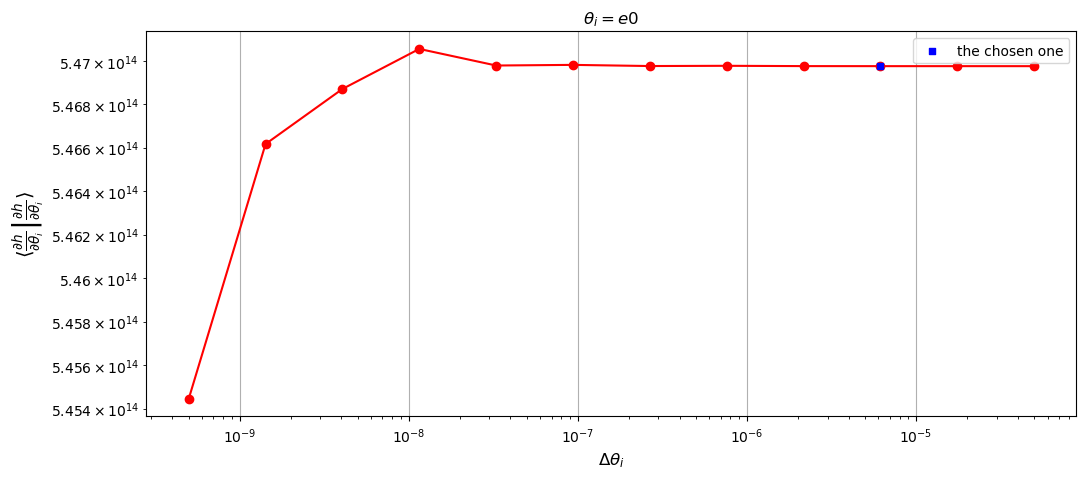

Gamma_ii for qS: 14632.203313281552
Gamma_ii for qS: 14632.203332440064
Gamma_ii for qS: 14632.203332444722
Gamma_ii for qS: 14632.20333244467
Gamma_ii for qS: 14632.203332444187
Gamma_ii for qS: 14632.20333244755
Gamma_ii for qS: 14632.203332444613
Gamma_ii for qS: 14632.203332468524
Gamma_ii for qS: 14632.203332433557
Gamma_ii for qS: 14632.203332679754
Gamma_ii for qS: 14632.20333244456
Gamma_ii for qS: 14632.203332967238
[np.float64(1.3093387861375539e-09), np.float64(3.1836844777515926e-13), np.float64(3.605109326622277e-15), np.float64(3.294324039844603e-14), np.float64(2.2985679810080267e-13), np.float64(2.0076729525844825e-13), np.float64(1.6341090378749164e-12), np.float64(2.38969022709354e-12), np.float64(1.6825666797649396e-11), np.float64(1.6073690718032318e-11), np.float64(3.5721039290389036e-11)]
2


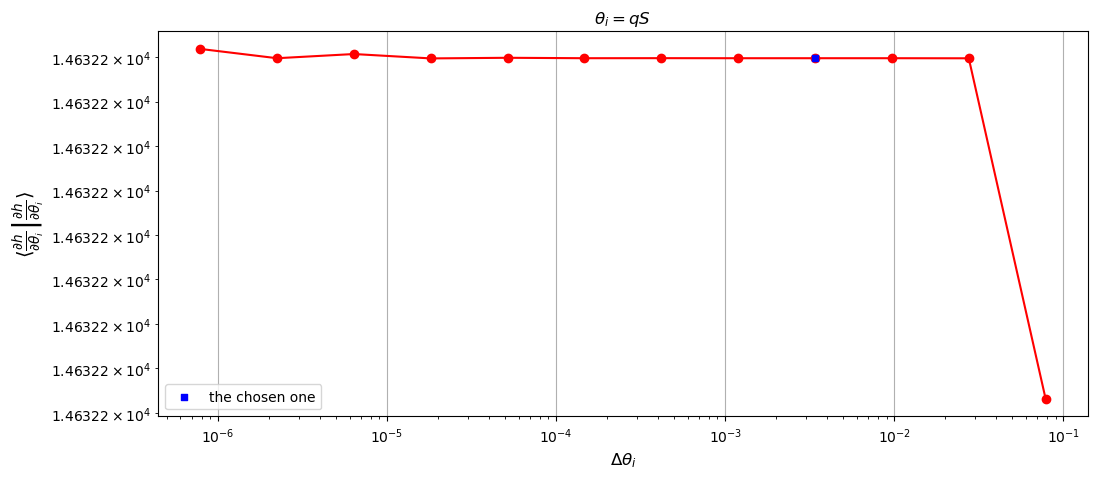

Gamma_ii for phiS: 283212.4508709202
Gamma_ii for phiS: 283212.450867387
Gamma_ii for phiS: 283212.4508673862
Gamma_ii for phiS: 283212.4508673862
Gamma_ii for phiS: 283212.4508673862
Gamma_ii for phiS: 283212.4508673862
Gamma_ii for phiS: 283212.4508673861
Gamma_ii for phiS: 283212.4508673865
Gamma_ii for phiS: 283212.45086738665
Gamma_ii for phiS: 283212.45086738566
Gamma_ii for phiS: 283212.4508673858
Gamma_ii for phiS: 283212.4508673959
[np.float64(1.2475457934940436e-11), np.float64(2.8773708581411304e-15), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(2.0552648986722364e-16), np.float64(1.2331589392033403e-15), np.float64(6.165794696016698e-16), np.float64(3.4939503277428077e-15), np.float64(4.1105297973444777e-16), np.float64(3.576160923689568e-14)]
2


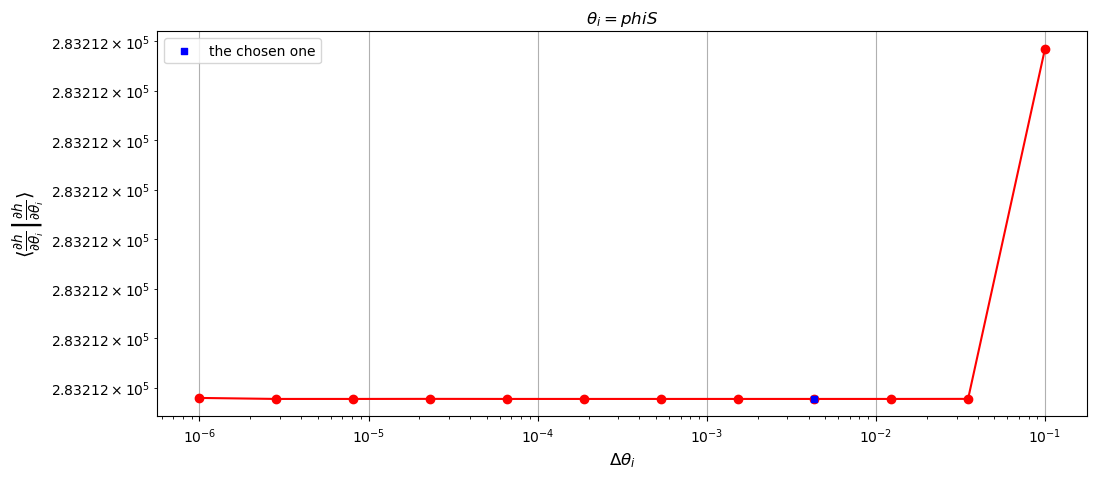

Gamma_ii for dev0p: 1270193585839.044
Gamma_ii for dev0p: 1270193416463.4985
Gamma_ii for dev0p: 1270191780736.0933
Gamma_ii for dev0p: 1270174328671.1438
Gamma_ii for dev0p: 1270224721954.85
Gamma_ii for dev0p: 1270201815635.3574
Gamma_ii for dev0p: 1269996217826.2815
Gamma_ii for dev0p: 1270108524542.4187
Gamma_ii for dev0p: 1267792946362.1174
Gamma_ii for dev0p: 1270738843424.8333
Gamma_ii for dev0p: 1278588602816.6316
Gamma_ii for dev0p: 1348589648866.7185
[np.float64(1.3334626302955932e-07), np.float64(1.2877798692143255e-06), np.float64(1.3739897394809765e-05), np.float64(3.967273100207386e-05), np.float64(1.8033606322014265e-05), np.float64(0.00016188852076097344), np.float64(8.842292919628085e-05), np.float64(0.0018264640034050758), np.float64(0.0023182553031716436), np.float64(0.006139394152666408), np.float64(0.05190685402999496)]
0


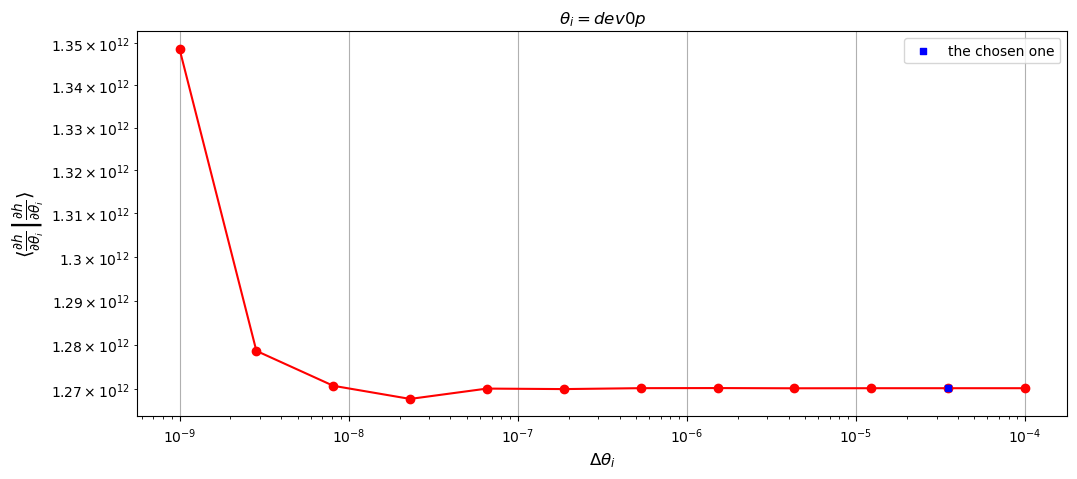

Gamma_ii for dev0e: 444294989261.416
Gamma_ii for dev0e: 444295706298.48956
Gamma_ii for dev0e: 444294718535.7
Gamma_ii for dev0e: 444296871187.53656
Gamma_ii for dev0e: 444307139469.7523
Gamma_ii for dev0e: 444323264275.5737
Gamma_ii for dev0e: 444473507171.6726
Gamma_ii for dev0e: 444823631343.87933
Gamma_ii for dev0e: 446737192633.43536
Gamma_ii for dev0e: 445219381302.14233
Gamma_ii for dev0e: 453391865444.6593
Gamma_ii for dev0e: 432212718680.0832
[np.float64(1.6138735157292717e-06), np.float64(2.223215240564271e-06), np.float64(4.845075390232092e-06), np.float64(2.3110774740225225e-05), np.float64(3.629070795494149e-05), np.float64(0.00033802441242206013), np.float64(0.0007871078502483065), np.float64(0.004283416113791491), np.float64(0.0034091313070285837), np.float64(0.01802521122539746), np.float64(0.04900167405821431)]
0


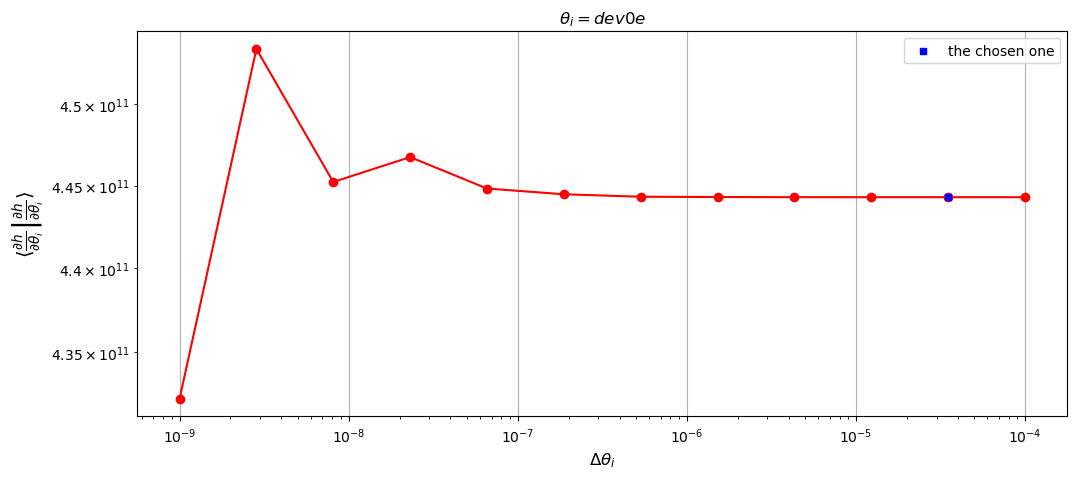

stable deltas: {'m1': 35.11191734215131, 'm2': 0.0003511191734215131, 'a': 4.155610829839735e-06, 'p0': 0.0002457834213950592, 'e0': 6.164233697210328e-06, 'qS': 0.00339980115994862, 'phiS': 0.004328761281083062, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': 3.511191734215135e-05, 'dev0e': 3.511191734215135e-05}
Time taken to compute stable deltas is 90.1035578250885 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 7.958715200424194 seconds


In [9]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}


param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}
der_order = 8
Ndelta = 12

Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )


In [10]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J

In [11]:
Fisher[-1].shape

(11, 11)

In [12]:
fisher_=Fisher[-1].copy()
fisher_
# sef.deltas["Phi_phi0"] = 1e-5
# sef.deltas["Phi_r0"] = 1e-5
sef.deltas

{'m1': 35.11191734215131,
 'm2': 0.0003511191734215131,
 'a': 4.155610829839735e-06,
 'p0': 0.0002457834213950592,
 'e0': 6.164233697210328e-06,
 'qS': 0.00339980115994862,
 'phiS': 0.004328761281083062,
 'Phi_phi0': 0.0,
 'Phi_r0': 0.0,
 'dev0p': 3.511191734215135e-05,
 'dev0e': 3.511191734215135e-05}

In [13]:
#in this code cell, we are transfroming fisher for numerical stability and will remove parameters that are causing problem

print("Transforming to log-mass")
Fisher_transform = logmasstransform(fisher_, m1)
print("Checking log-mass Fisher positive-definiteness...")
check_flag = True
rows_to_remove = []
for j in range(len(param_names)):
    if param_names[j] in []:#'dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']:
            rows_to_remove.append(j)

rows_to_remove = np.array(rows_to_remove)
    
if len(rows_to_remove) > 0:
    Fisher_transformed = np.delete(np.delete(Fisher_transform,rows_to_remove,axis=0),rows_to_remove,axis=1)
    #Fisher = np.delete(np.delete(Fisher,rows_to_remove,axis=0),rows_to_remove,axis=1)

if (np.linalg.eigvals(Fisher_transform) < 0.0).any():
    check_flag = False
    print('positive definiteness failed for: ', i)
        
if check_flag:
    print("positive-definiteness check passed!")
pd.DataFrame(Fisher_transform)

Transforming to log-mass
Checking log-mass Fisher positive-definiteness...
positive-definiteness check passed!


,0,1,2,3,4,5,6,7,8,9,10
0,3.865348e+14,-3.432745e+12,1.753119e+13,7.983937e+13,4.584286e+14,-1.915384e+09,8.836458e+09,-2.316257e+09,-2.994669e+09,-2.145405e+13,-1.287762e+13
1,-3.432745e+12,3.211467e+10,-1.767938e+11,-7.122350e+11,-3.998128e+12,1.535768e+07,-7.084871e+07,1.857104e+07,2.303476e+07,2.018823e+11,1.193020e+11
2,1.753119e+13,-1.767938e+11,1.586699e+12,3.741490e+12,1.986251e+13,-8.408195e+07,3.881436e+08,-1.017508e+08,-6.546277e+07,-1.129142e+12,-6.389900e+11
3,7.983937e+13,-7.122350e+11,3.741490e+12,1.650926e+13,9.454832e+13,-3.952029e+08,1.823271e+09,-4.779262e+08,-6.077932e+08,-4.455001e+12,-2.668220e+12
4,4.584286e+14,-3.998128e+12,1.986251e+13,9.454832e+13,5.469760e+14,-2.347022e+09,1.082786e+10,-2.838265e+09,-3.712710e+09,-2.493582e+13,-1.505045e+13
5,-1.915384e+09,1.535768e+07,-8.408195e+07,-3.952029e+08,-2.347022e+09,1.463220e+04,-6.119146e+04,1.603918e+04,1.988295e+04,9.535851e+07,5.823711e+07
6,8.836458e+09,-7.084871e+07,3.881436e+08,1.823271e+09,1.082786e+10,-6.119146e+04,2.832125e+05,-7.401499e+04,-9.171701e+04,-4.399205e+08,-2.686626e+08
7,-2.316257e+09,1.857104e+07,-1.017508e+08,-4.779262e+08,-2.838265e+09,1.603918e+04,-7.401499e+04,1.940222e+04,2.404267e+04,1.153132e+08,7.042223e+07
8,-2.994669e+09,2.303476e+07,-6.546277e+07,-6.077932e+08,-3.712710e+09,1.988295e+04,-9.171701e+04,2.404267e+04,3.818141e+04,1.416148e+08,8.876514e+07
9,-2.145405e+13,2.018823e+11,-1.129142e+12,-4.455001e+12,-2.493582e+13,9.535851e+07,-4.399205e+08,1.153132e+08,1.416148e+08,1.270193e+12,7.488651e+11


In [14]:
delats=sef.deltas
param_name = sef.param_names

In [15]:
parameters = {}
for i in range(len(param_names_com)):
    parameters[param_names_com[i]] = pars_list_com[i]


order = 8 #order of finite-difference derivative
kind = "central" #kind of finite-difference derivative
parameters

{'m1': 1000000.0,
 'm2': 10,
 'a': 0.96,
 'p0': 7.0,
 'e0': 0.5,
 'xI0': 1.0,
 'dist': 0.4,
 'qS': 0.7853981633974483,
 'phiS': 1.0,
 'qK': 1,
 'phiK': 1.0471975511965976,
 'Phi_phi0': 0.9,
 'Phi_theta0': 0.5,
 'Phi_r0': 0.4,
 'chi2': 0.0,
 'evolve_1PA': False,
 'evolve_primary': False,
 'evolve_2PA': False,
 'deviation_included': True,
 'dev0p': 0.0,
 'dev0e': 0.0,
 'dev1p': 0.0,
 'dev1e': 0.0,
 'dev2p': 0.0,
 'dev2e': 0.0}

In [16]:
# del sef
sef.wave_params_list

[1000000.0,
 10,
 0.96,
 7.0,
 0.5,
 1.0,
 0.4,
 0.7853981633974483,
 1.0,
 1,
 1.0471975511965976,
 0.9,
 0.5,
 0.4,
 0.0,
 False,
 False,
 False,
 True,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [17]:
sef.waveform_derivative_kwargs

{'parameters': {'m1': 1000000.0,
  'm2': 10,
  'a': 0.96,
  'p0': 7.0,
  'e0': 0.5,
  'xI0': 1.0,
  'dist': 0.4,
  'qS': 0.7853981633974483,
  'phiS': 1.0,
  'qK': 1,
  'phiK': 1.0471975511965976,
  'Phi_phi0': 0.9,
  'Phi_theta0': 0.5,
  'Phi_r0': 0.4,
  'chi2': 0.0,
  'evolve_1PA': False,
  'evolve_primary': False,
  'evolve_2PA': False,
  'deviation_included': True,
  'dev0p': 0.0,
  'dev0e': 0.0,
  'dev1p': 0.0,
  'dev1e': 0.0,
  'dev2p': 0.0,
  'dev2e': 0.0},
 'order': 8,
 'dt': 10.0,
 'T': 0.4}

In [18]:
print(f"Calculating Cutler-Vallisneri Biases")
removed_params = []
print(f'calculating derivatives at {param_names}...')
#Fisher = np.zeros((sef.npar,sef.npar), dtype=np.float64)
dtv = []

for k in range(sef.npar):
        temp=sef.derivative(*sef.wave_params_list,
                             param_to_vary=sef.param_names[k],
                               delta=sef.deltas[sef.param_names[k]],
                               kind=kind, **sef.waveform_derivative_kwargs,use_gpu=use_gpu)
        print(temp)
        print("\n",temp.shape)
        print(f"calculting derivative for {sef.param_names[k]}\n")
        dtv_=np.vstack([temp.real,temp.imag])
        print(dtv_)
        dtv.append(dtv_)
        

print("Finished derivatives")
if sef.use_gpu:
        dtv = cp.asnumpy(cp.asarray(dtv)) #h5py only stores numpy
          
#Jacobian transform to log-masses
for k in range(sef.npar):
    if sef.param_names[k] == 'm1':
        dtv[k] *= m1 #to obtain \partial_{log m1}h

Calculating Cutler-Vallisneri Biases
calculating derivatives at ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0', 'dev0p', 'dev0e']...
[ 1.30526811e-32+1.14346762e-32j  2.23115432e-28-9.82046244e-29j
  4.40056181e-28-4.71485719e-29j ... -1.04837518e-23-5.09845327e-23j
 -5.14015953e-24-5.19414204e-23j  3.78515023e-25-5.23831282e-23j]

 (1262326,)
calculting derivative for m1

[[ 1.30526811e-32  2.23115432e-28  4.40056181e-28 ... -1.04837518e-23
  -5.14015953e-24  3.78515023e-25]
 [ 1.14346762e-32 -9.82046244e-29 -4.71485719e-29 ... -5.09845327e-23
  -5.19414204e-23 -5.23831282e-23]]
[ 1.30526811e-22+1.14346757e-22j  8.80477965e-23+1.42084179e-22j
  4.33020674e-23+1.54067670e-22j ...  1.36974237e-19+6.77326215e-19j
  6.46555463e-20+6.89174564e-19j -9.62859899e-21+6.93877677e-19j]

 (1262326,)
calculting derivative for m2

[[ 1.30526811e-22  8.80477965e-23  4.33020674e-23 ...  1.36974237e-19
   6.46555463e-20 -9.62859899e-21]
 [ 1.14346757e-22  1.42084179e-22  1.54067670e-

In [19]:
params_truth_in = np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,dev_0_p,dev_0_e])
#params_truth_in_transformed = np.array([np.log(m1), m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,dev_0_p,dev_0_e])

# param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0,Phi_r0,dev_0_p,dev_0_e])
#params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, dev_0_p, dev_0_e])
print(params_truth_in_considered)
waveform_approx = sef.waveform
waveform_approx

[13.81551056 10.          0.96        7.          0.5         0.78539816
  1.          0.9         0.4         0.          0.        ]


array([[ 6.52640580e-22,  4.40242155e-22,  2.16510088e-22, ...,
         3.09828013e-22,  3.15230960e-22,  3.16906173e-22],
       [-5.71739504e-22, -7.10428517e-22, -7.70346265e-22, ...,
         6.65822139e-23,  3.12017077e-23, -4.67544769e-24]],
      shape=(2, 1262326))

In [20]:
#initializing the 1PA (True GR model in our analysis)
evolve_1PA = True 
evolve_primary = False
evolve_2PA = False #for approximate model
dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
deviation_included=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)
waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)

[0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


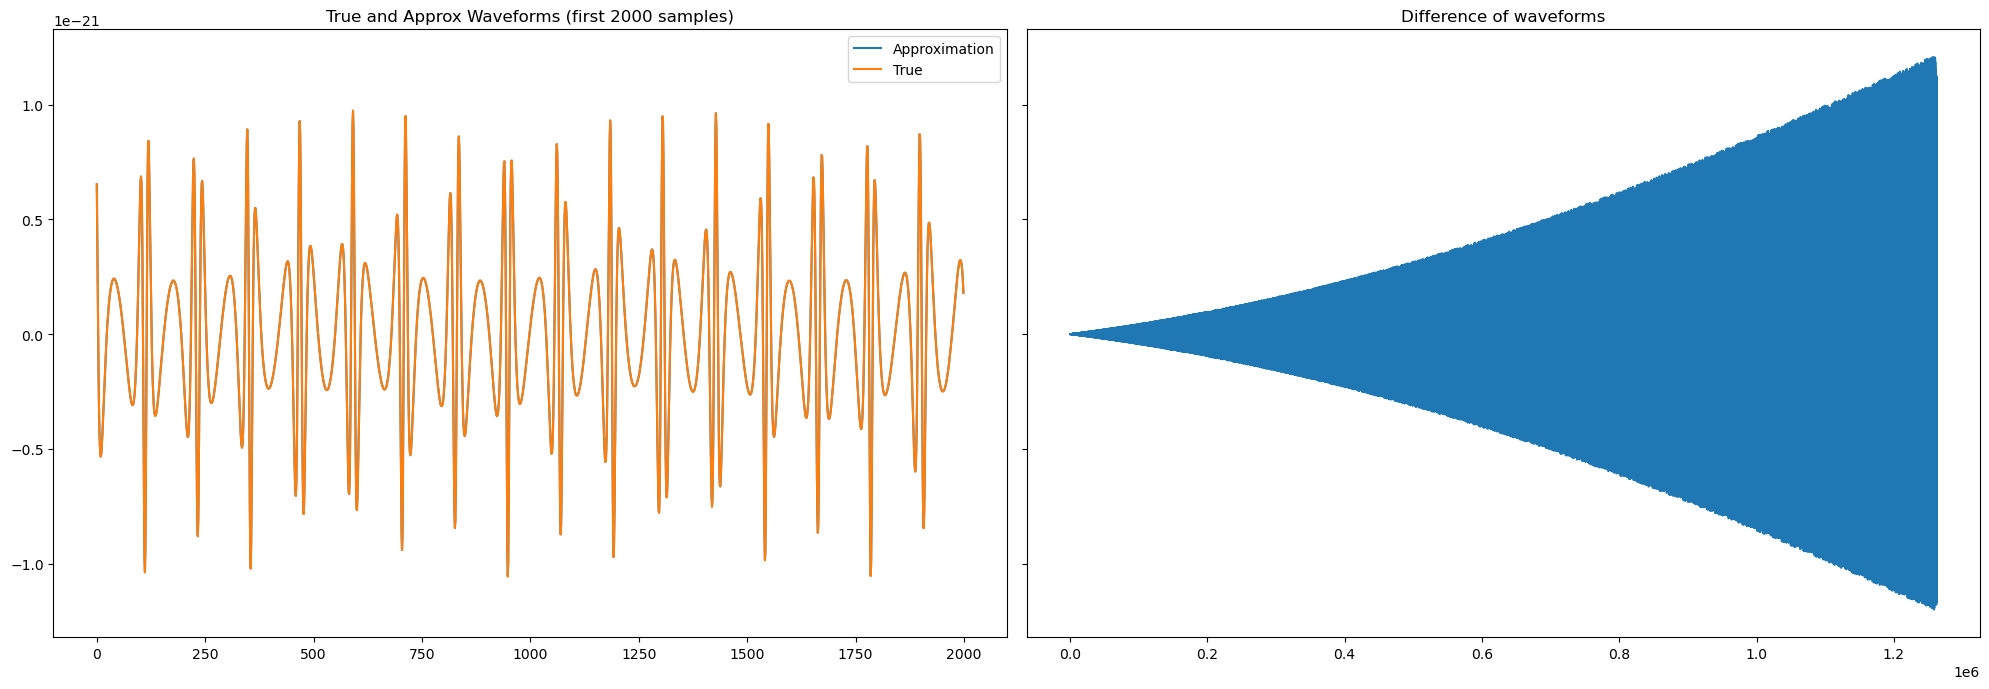

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Plot the first 2000 samples of both waveforms
axs[0].plot(waveform_approx[0][0:2000].get(), label="Approximation")
axs[0].plot(waveform_true[0][0:2000].get(), label="True")
axs[0].set_title("True and Approx Waveforms (first 2000 samples)")
axs[0].legend()

# Plot the difference
axs[1].plot(((waveform_true[0] - waveform_approx[0])[0:]).get())
axs[1].set_title("Difference of waveforms")

plt.tight_layout()

In [22]:
biased_params = cutlervallis(waveform_truth=waveform_true, waveform_approx=waveform_approx,
                                 Fisher_truth=Fisher_transform, partial_approx=dtv,
                                 params_truth=params_truth_in_considered, PSD_func = sef.PSD_funcs, dt = dt,
                                  use_gpu=use_gpu)
print(biased_params)

if use_gpu:
        biased_params = cp.asnumpy(cp.asarray(biased_params))

#prior box on chi2
# if 'chi2' not in removed_params:
#     index_chi2 = np.where(param_names == 'chi2')
        
#     if biased_params[index_chi2] > 1.0:
#         biased_params[index_chi2] = 1.0
#     elif biased_params[index_chi2] < -1.0:
#         biased_params[index_chi2] = -1.0

#prior box on cyclic parameters (phases and such)
cyclic_priors = {'qS' : np.pi, 'phiS' : 2 * np.pi, 'qK' : np.pi, 'phiK' : 2 * np.pi, 'Phi_phi0' : 2 * np.pi, 'Phi_r0' : 2 * np.pi}
param_names_in = np.array(param_names)
for param in list(cyclic_priors.keys()):
    if param not in removed_params:
        print(f"modulo {cyclic_priors[param]} for param {param}")
            
        index = np.where(param_names_in == param) 
        biased_params[index] %= cyclic_priors[param]


print('biased params: ', biased_params)

#calculate the sigma contour as the Mahalanobis distance between the true and biased params (https://en.wikipedia.org/wiki/Mahalanobis_distance):
    
sigma_contour = np.sqrt((biased_params - params_truth_in_considered)@Fisher_transform@(biased_params - params_truth_in_considered))
sigma_contour /= np.sqrt(len(params_truth_in_considered)) #scaled Mahalonobis distance for dimensional generality
    
print('sigma contours: ', sigma_contour)

delta_wave.shape, partial_approx.shape:  (2, 1262326) (2, 1262326)
inner_prod at j = 0:  83279.60040384726
delta_wave.shape, partial_approx.shape:  (2, 1262326) (2, 1262326)
inner_prod at j = 1:  -750.3559140559022
delta_wave.shape, partial_approx.shape:  (2, 1262326) (2, 1262326)
inner_prod at j = 2:  4724.539599975136
delta_wave.shape, partial_approx.shape:  (2, 1262326) (2, 1262326)
inner_prod at j = 3:  17346.06814488504
delta_wave.shape, partial_approx.shape:  (2, 1262326) (2, 1262326)
inner_prod at j = 4:  98306.80534885697
delta_wave.shape, partial_approx.shape:  (2, 1262326) (2, 1262326)
inner_prod at j = 5:  -1.5147482590960382
delta_wave.shape, partial_approx.shape:  (2, 1262326) (2, 1262326)
inner_prod at j = 6:  -0.9303736570431738
delta_wave.shape, partial_approx.shape:  (2, 1262326) (2, 1262326)
inner_prod at j = 7:  -0.5246434880311863
delta_wave.shape, partial_approx.shape:  (2, 1262326) (2, 1262326)
inner_prod at j = 8:  -0.5810493779587284
delta_wave.shape, partial_ap

In [23]:
print(sigma_contour)

0.03189029883612835


In [24]:
biased_params

array([ 1.38155288e+01,  1.00013716e+01,  9.60009260e-01,  6.99993949e+00,
        4.99996146e-01,  7.84399327e-01,  9.96551268e-01,  8.87673452e-01,
        4.00010117e-01, -1.21368144e-04, -1.16013921e-04])

In [25]:
params_truth_in_considered

array([13.81551056, 10.        ,  0.96      ,  7.        ,  0.5       ,
        0.78539816,  1.        ,  0.9       ,  0.4       ,  0.        ,
        0.        ])

# plot ig

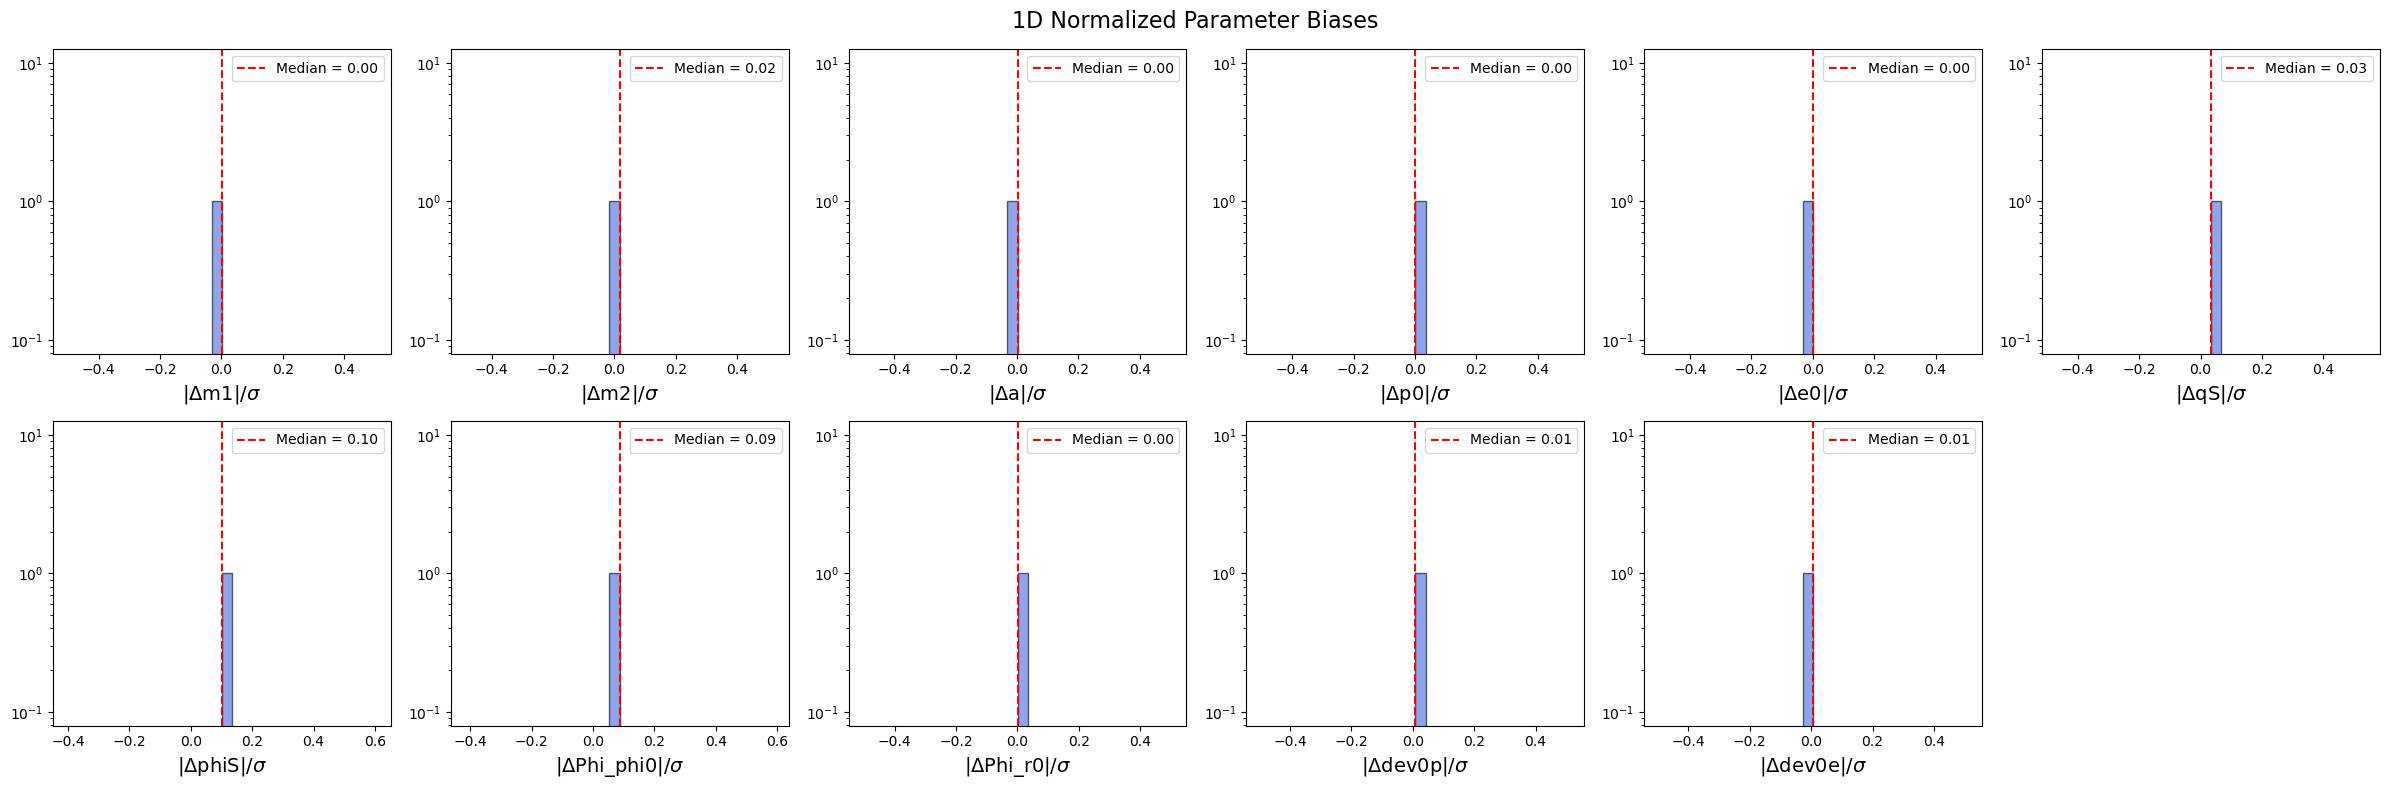

In [26]:
#used gpt (boring part)

# === PARAMETERS ===
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']


params_truth_in_considered = np.array([
    np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_0_p, dev_0_e
])
truevals_i = params_truth_in_considered

Fisher_transformed = Fisher_transform.copy()

# === REMOVE PARAMETERS IF SPECIFIED ===
rows_to_remove = [i for i, name in enumerate(param_names) if name in removed_params]
rows_to_remove = np.array(rows_to_remove)

if len(rows_to_remove) > 0:
    Fisher_transformed = np.delete(Fisher_transformed, rows_to_remove, axis=0)
    Fisher_transformed = np.delete(Fisher_transformed, rows_to_remove, axis=1)
   # param_names_plot = np.delete(param_names_plot, rows_to_remove, axis=0)
    truevals_i = np.delete(truevals_i, rows_to_remove, axis=0)

# === COMPUTE SIGMAS ===
covariance = np.linalg.inv(Fisher_transformed)
sigmas_params = np.sqrt(np.diag(covariance))

# === COMPUTE NORMALIZED BIASES ===
sigmabias_1D = np.abs(biased_params - truevals_i) / sigmas_params

# === PLOT ===
n_params = len(param_names)
ncols = int(np.ceil(n_params / 2))

fig, axs = plt.subplots(2, ncols, figsize=(4 * ncols, 8))
axs = axs.flatten()

for i, name in enumerate(param_names):
    axs[i].hist(sigmabias_1D[i], bins=30, histtype='stepfilled',
                color='royalblue', alpha=0.6, edgecolor='k')
    axs[i].set_xlabel(r"$|\Delta $" + rf"{name}" + r"$|/\sigma$", fontsize=14)
    axs[i].set_yscale('log')
    axs[i].axvline(np.median(sigmabias_1D[i]), color='r', linestyle='--',
                   label=f"Median = {np.median(sigmabias_1D[i]):.2f}")
    axs[i].legend(fontsize=10)

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle("1D Normalized Parameter Biases", fontsize=16)
plt.show()



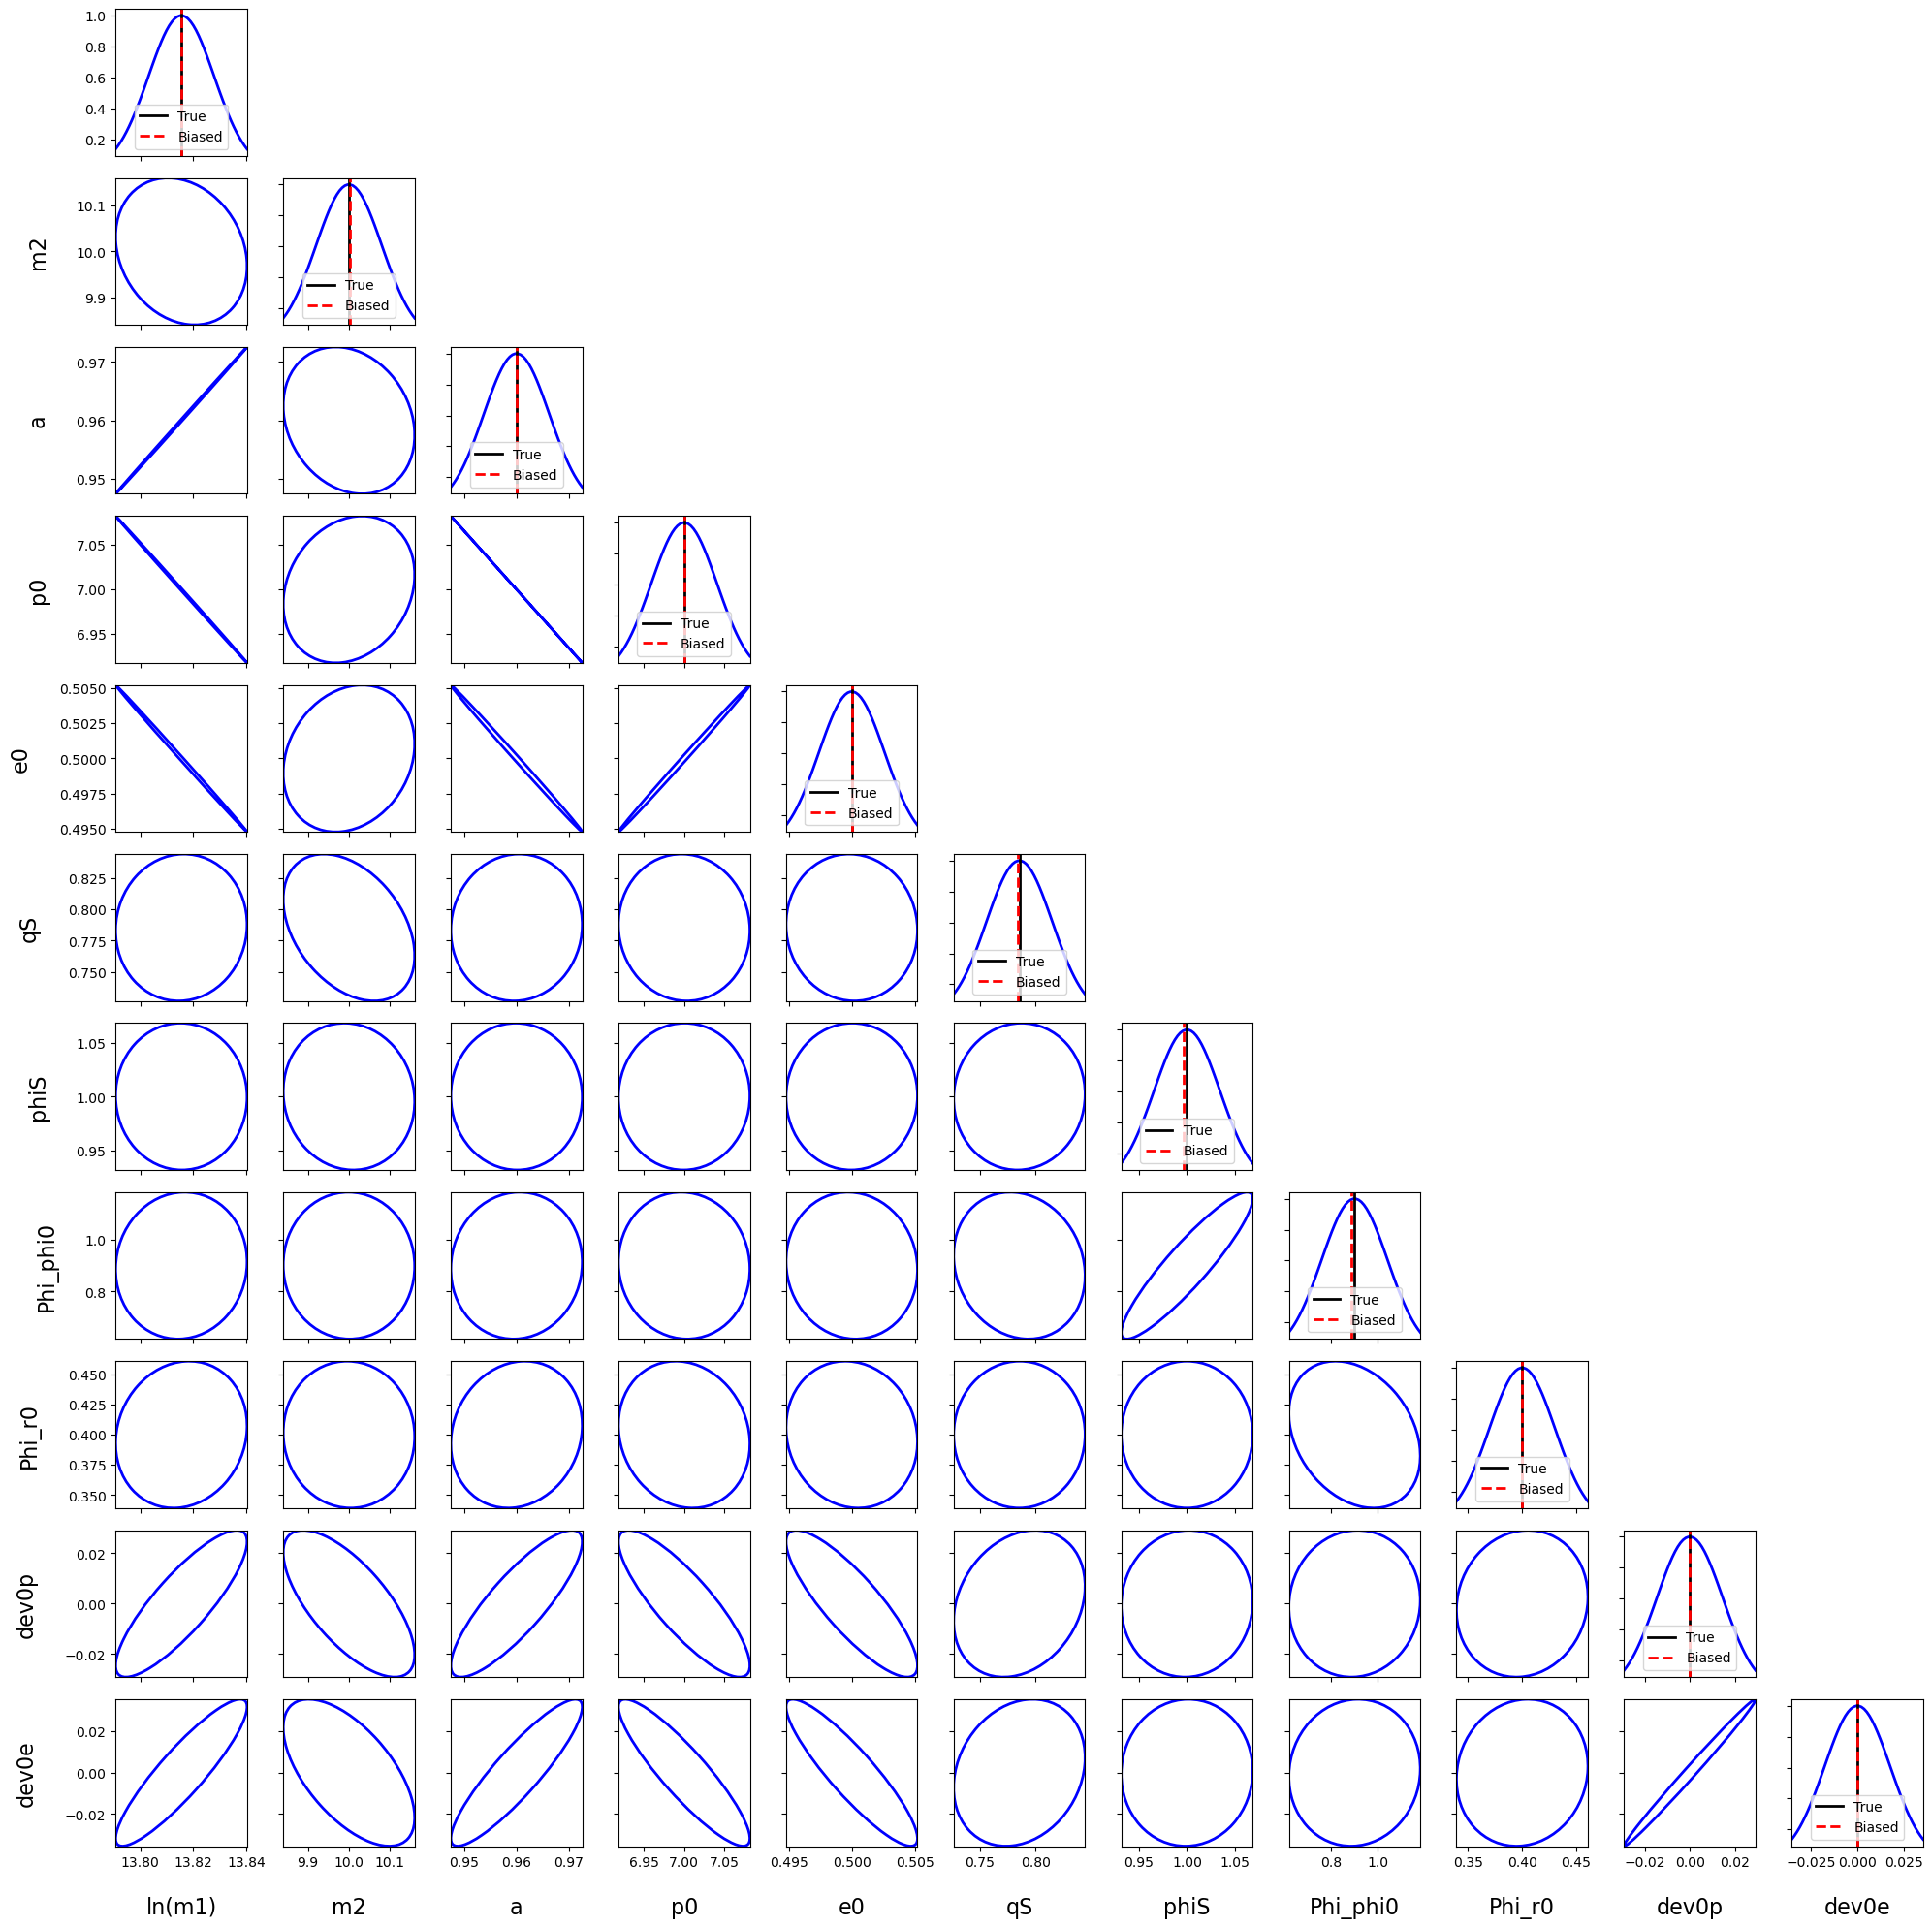

In [27]:
from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = params_truth_in_considered
# param_names_plot = [
#     r'$\log{m_1}$', r'$m_2$', r'$a$', r'$p_0$', r'$e_0$',
#     r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
#     r'dev0_p', r'dev0_e'
# ]
param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = params_truth_in_considered[i]

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)
# === ADD TRUE AND BIASED PARAMETER LINES ===
for i in range(len(param_names)):
    # Diagonal subplot (1D)
    ax = axs[i, i]
    ax.axvline(params_truth_in_considered[i], color='k', linestyle='-', lw=2, label='True')
    ax.axvline(biased_params[i], color='r', linestyle='--', lw=2, label='Biased')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


In [28]:
biased_params

array([ 1.38155288e+01,  1.00013716e+01,  9.60009260e-01,  6.99993949e+00,
        4.99996146e-01,  7.84399327e-01,  9.96551268e-01,  8.87673452e-01,
        4.00010117e-01, -1.21368144e-04, -1.16013921e-04])

In [29]:
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
dev_0_p=biased_params[9]
dev_0_e=biased_params[10]
# param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
deviation_included=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

pars_list = [np.exp(biased_params[0]), biased_params[1], biased_params[2], biased_params[3], \
             biased_params[4], xI0, dist, biased_params[5], biased_params[6], qK, phiK, biased_params[7], Phi_theta0,\
               biased_params[8]]

superkludge_wave_biased = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)

waveform_biased = superkludge_wave_biased(*pars_list, *add_args, dt=dt, T=T)


In [30]:
deviation=params_truth_in_considered-biased_params
print("Higher",biased_params)
print("\nTrue",params_truth_in_considered)
print("\nlower",params_truth_in_considered+deviation)

Higher [ 1.38155288e+01  1.00013716e+01  9.60009260e-01  6.99993949e+00
  4.99996146e-01  7.84399327e-01  9.96551268e-01  8.87673452e-01
  4.00010117e-01 -1.21368144e-04 -1.16013921e-04]

True [13.81551056 10.          0.96        7.          0.5         0.78539816
  1.          0.9         0.4         0.          0.        ]

lower [1.38154923e+01 9.99862838e+00 9.59990740e-01 7.00006051e+00
 5.00003854e-01 7.86397000e-01 1.00344873e+00 9.12326548e-01
 3.99989883e-01 1.21368144e-04 1.16013921e-04]


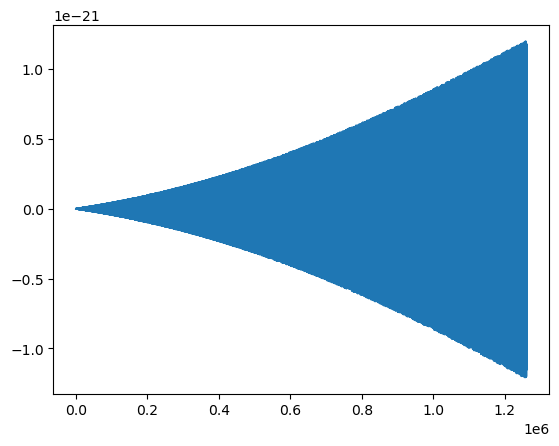

In [31]:
plt.plot((waveform_approx-waveform_true)[0].get())

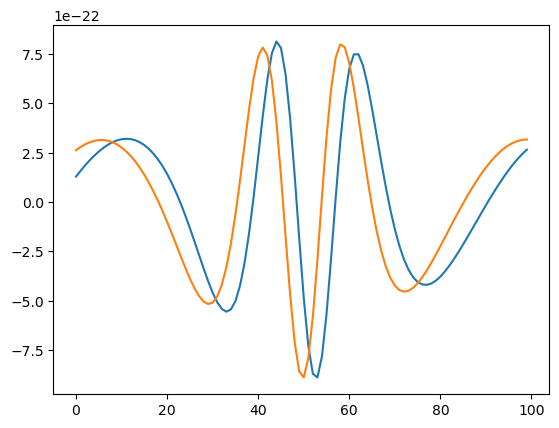

In [32]:
plt.plot((waveform_true)[0][-100:].get())
plt.plot((waveform_biased)[0][-100:].get())

In [33]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner=inner_product(waveform_biased,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_biased=np.sqrt(inner_product(waveform_biased,waveform_biased,PSD,dt,use_gpu=use_gpu))
diff_inner/((norm_true)*norm_biased)


np.float64(0.8547064819552824)

In [41]:
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
deviation_included=True
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0

deviation=biased_params-params_truth_in_considered

PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])

norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
delta = np.linspace(-40,40,1000)
save_inner=[]
for i in range(len(delta)):
    biased = params_truth_in_considered + delta[i] * deviation
    dev_0_p= biased[9]
    dev_0_e= biased[10]
    add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
    add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,\
                    "deviation_included":deviation_included,"dev0p":dev_0_p,
        "dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

    pars_list = [np.exp(biased[0]), biased[1], biased[2], biased[3], \
             biased[4], xI0, dist, biased[5], biased[6], qK, phiK, biased[7], Phi_theta0,\
               biased[8]]
    waveform_considered = superkludge_wave_biased(*pars_list, *add_args, dt=dt, T=T,use_gpu=use_gpu)
    diff_inner=inner_product(waveform_considered,waveform_true,PSD,dt,use_gpu=use_gpu)
    norm_biased=np.sqrt(inner_product(waveform_considered,waveform_considered,PSD,dt,use_gpu=use_gpu))
    mismatch=diff_inner/((norm_true)*norm_biased)
   #print(mismatch)
    save_inner.append(mismatch)


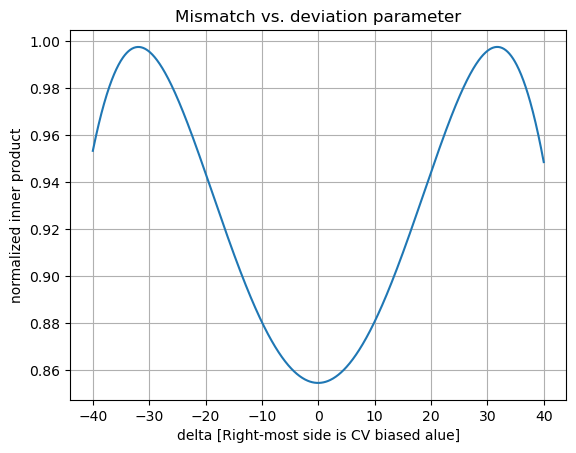

In [42]:
plt.plot(delta,save_inner)
plt.xlabel("delta [Right-most side is CV biased alue]")
plt.ylabel("normalized inner product")
plt.title("Mismatch vs. deviation parameter")
plt.grid(True)

In [36]:
print(np.max(save_inner))
delta[np.argmax(save_inner)]
#0.8587424254524265

0.855531834304631


np.float64(2.0)

In [37]:
print(np.max(save_inner))
delta[np.argmax(save_inner)]
#0.8587424254524265

0.855531834304631


np.float64(2.0)

In [38]:
print(np.max(save_inner))
delta[np.argmax(save_inner)]
#0.8587424254524265

0.855531834304631


np.float64(2.0)